# Profiling

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
#Load Data
df = pd.read_csv("../data/raw/dataset_raw.csv")
df.head()

,timestamp,machine_id,line,age_months,last_maintenance_days,temp_c,vibration_mm_s,current_a,load_pct,lubricant_level_pct,alarm_count,downtime_next_24h,maintenance_ticket_closed,failure_mode
0,2026-01-01 00:00:00,MX-01,L1,12,82,71.70,3.50,36.66,101.3,30.0,2,0,0,none
1,2026-01-01 01:00:00,MX-02,L2,18,10,70.26,2.43,33.56,65.0,70.9,1,0,0,none
2,2026-01-01 02:00:00,MX-03,L3,25,62,73.42,2.44,33.71,77.3,40.0,1,0,0,none
3,2026-01-01 03:00:00,MX-04,L4,29,69,80.25,4.17,33.20,71.0,29.0,2,0,0,none
4,2026-01-01 04:00:00,MX-05,L1,40,41,77.07,2.77,31.24,63.9,62.2,0,0,0,none


| Kolom | Tipe Data | Deskripsi Bisnis |
|---------|---------|---------|
| `timestamp` | Datetime | Waktu observasi kondisi mesin. Digunakan untuk analisis tren dan pola downtime dari waktu ke waktu. |
| `machine_id` | Kategorikal | Identitas unik mesin. Digunakan untuk segmentasi performa dan risiko downtime antar mesin. |
| `line` | Kategorikal | Lini produksi atau area operasi tempat mesin berada. Dapat digunakan untuk membandingkan tingkat risiko antar lini produksi. |
| `age_months` | Numerik | Umur mesin dalam bulan. Semakin tua mesin, semakin besar kemungkinan mengalami penurunan performa dan downtime. |
| `last_maintenance_days` | Numerik | Jumlah hari sejak maintenance terakhir dilakukan. Nilai yang tinggi dapat menunjukkan peningkatan risiko kerusakan karena maintenance yang tertunda. |
| `temp_c` | Numerik | Temperatur operasi mesin (°C). Temperatur tinggi dapat mengindikasikan overheating atau kondisi operasi yang tidak normal. |
| `vibration_mm_s` | Numerik | Tingkat getaran mesin (mm/s). Getaran berlebih sering menjadi indikator awal kerusakan komponen mekanis. |
| `current_a` | Numerik | Arus listrik yang digunakan mesin (Ampere). Nilai abnormal dapat mengindikasikan beban berlebih atau gangguan kelistrikan. |
| `load_pct` | Numerik (%) | Persentase beban operasi mesin terhadap kapasitas maksimalnya. Beban tinggi dalam jangka panjang dapat mempercepat keausan mesin. |
| `lubricant_level_pct` | Numerik (%) | Persentase pelumas yang tersedia pada mesin. Pelumas yang rendah dapat meningkatkan gesekan dan risiko kerusakan komponen. |
| `alarm_count` | Numerik | Jumlah alarm yang muncul selama periode observasi. Semakin banyak alarm dapat menunjukkan kondisi mesin yang tidak stabil. |
| `downtime_next_24h` | Biner (0/1) | Variabel target. Bernilai 1 jika mesin mengalami downtime dalam 24 jam setelah observasi dan 0 jika tidak. |
| `maintenance_ticket_closed` | Kategorikal/Numerik | Status penyelesaian tiket maintenance. Informasi ini baru diketahui setelah maintenance dilakukan sehingga berpotensi menyebabkan data leakage jika digunakan sebagai fitur model. |
| `failure_mode` | Kategorikal | Jenis kegagalan mesin yang terjadi. Berguna untuk analisis akar penyebab kerusakan, namun perlu dievaluasi karena kemungkinan baru diketahui setelah downtime terjadi. |

In [18]:
# Lihat ringkasan informasi tiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   timestamp                  2400 non-null   object 
 1   machine_id                 2400 non-null   object 
 2   line                       2400 non-null   object 
 3   age_months                 2400 non-null   int64  
 4   last_maintenance_days      2400 non-null   int64  
 5   temp_c                     2400 non-null   float64
 6   vibration_mm_s             2400 non-null   float64
 7   current_a                  2400 non-null   float64
 8   load_pct                   2400 non-null   float64
 9   lubricant_level_pct        2328 non-null   float64
 10  alarm_count                2400 non-null   int64  
 11  downtime_next_24h          2400 non-null   int64  
 12  maintenance_ticket_closed  2400 non-null   int64  
 13  failure_mode               2400 non-null   objec

> Ringkasan
- Total baris: 2.400 entri (index 0–2399)
- Total kolom: 14
- hampir semua kolom sudah sesuai dengan format/type data kecuali timestamp yang mana seharusnya type data datetime
- ada indikasi missing value di kolom lubricant_level_pct karena jumlah baris tidak sama dengan bari kolom lain di mana seharusnya ada 2400 baris namun pada kolom tersebut hanya 2328 baris

In [19]:
# Lihat nilai statistika deskriptif tiap kolom
df.describe()

,age_months,last_maintenance_days,temp_c,vibration_mm_s,current_a,load_pct,lubricant_level_pct,alarm_count,downtime_next_24h,maintenance_ticket_closed
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2328.000000,2400.000000,2400.000000,2400.000000
mean,48.495833,48.460417,75.508183,11.655967,32.121454,73.014750,51.262113,1.314583,0.027917,0.052083
std,24.214254,27.280522,5.004647,90.532464,3.016798,12.988276,19.325984,1.586664,0.164768,0.222241
min,8.000000,1.000000,56.360000,0.190000,22.650000,25.000000,2.000000,0.000000,0.000000,0.000000
25%,28.250000,25.000000,72.030000,2.770000,30.140000,64.300000,37.200000,0.000000,0.000000,0.000000
50%,48.500000,48.000000,75.485000,3.370000,32.135000,73.100000,51.300000,1.000000,0.000000,0.000000
75%,68.750000,72.000000,78.880000,3.930000,34.072500,81.800000,65.300000,2.000000,0.000000,0.000000
max,89.000000,95.000000,92.790000,999.000000,41.960000,105.000000,100.000000,14.000000,1.000000,1.000000


> Ringkasan
- Adanya nilai ekstrem/outlier pada kolom vibration_mm_s, di mana nilai median 3.37, sedangkan nilai max 999.00
- Adanya data invalid pada load_pct, dapat dilihat pada nilai maxnya yakni 105% yang mana ini tidak masuk akal, karena seharusnya nilai maxnya adalah 100%

In [20]:
# Melihat jumlah data duplikat
df.duplicated().sum()

0

> Ringkasan
- Dapat dilihat pada pengecekan duplikat pada data set, tidak terdapat satu pun baris yang duplikat

In [21]:
# Melihat jumlah data kosong
df.isnull().sum()

timestamp                     0
machine_id                    0
line                          0
age_months                    0
last_maintenance_days         0
temp_c                        0
vibration_mm_s                0
current_a                     0
load_pct                      0
lubricant_level_pct          72
alarm_count                   0
downtime_next_24h             0
maintenance_ticket_closed     0
failure_mode                  0
dtype: int64

> Ringkasan
- Dapat dilihat juga, pengecekan ulang untuk missing value pada data. Terdapat 72 baris yang missing value pada lubricant_level_pct 

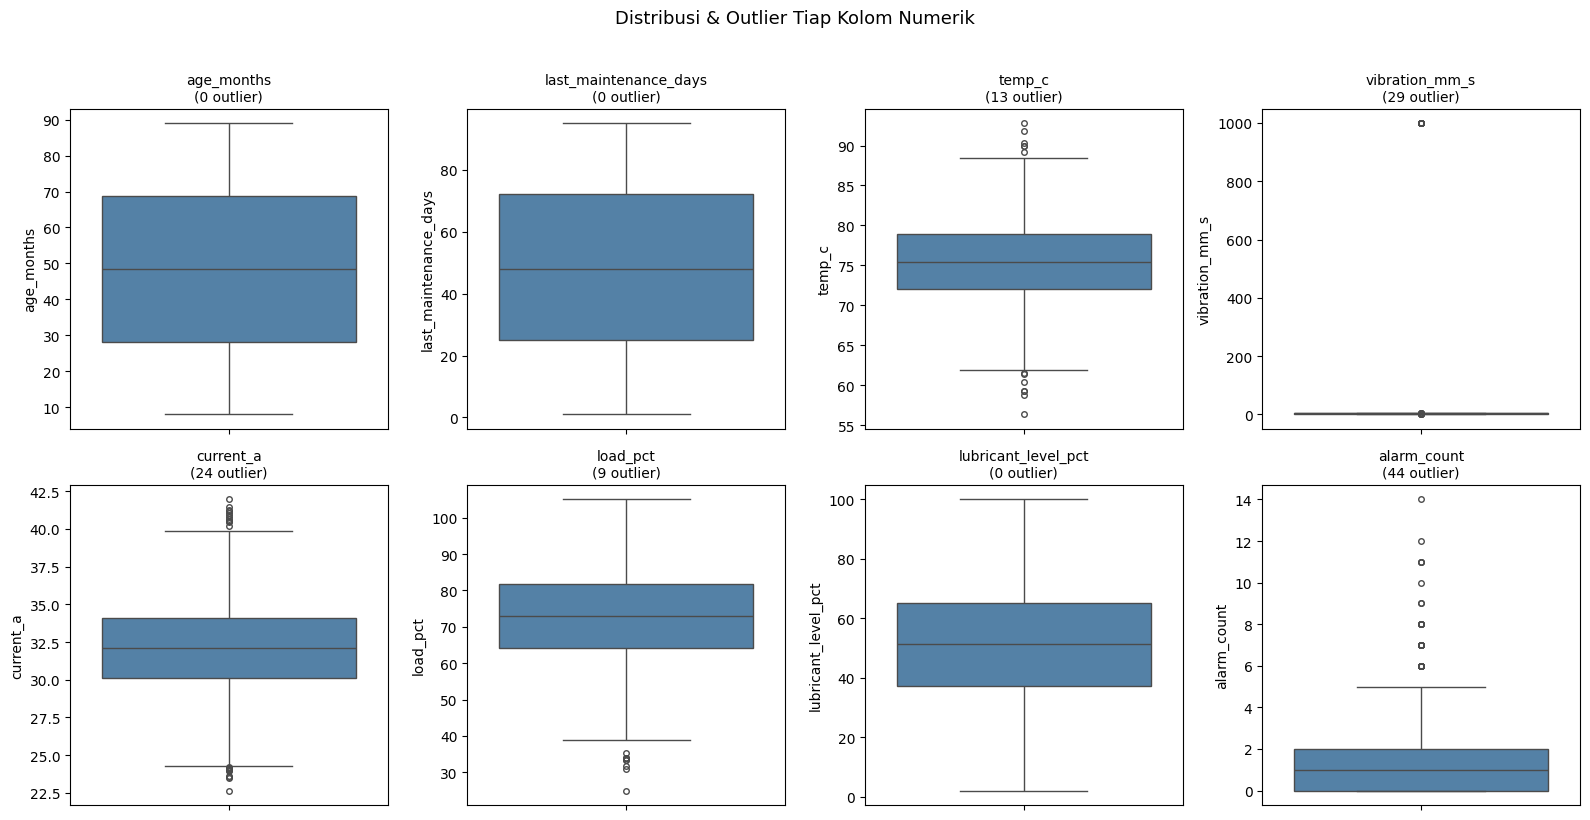

In [22]:
# Cek Outlier
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for col, ax in zip(df.select_dtypes(include='number').columns, axes):
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    
    sns.boxplot(y=df[col], ax=ax, color='steelblue', flierprops=dict(marker='o', color='red', markersize=4))
    ax.set_title(f"{col}\n({n_out} outlier)", fontsize=10)
    ax.set_xlabel('')

plt.suptitle('Distribusi & Outlier Tiap Kolom Numerik', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> Ringkasan
- Terdapat outlier di beberapa kolom, seoerti tempt_c, lalu vibration_mm_s, current_a,load_pct, dan alarm_count

In [23]:
# Pengecekan proporsi target
df['downtime_next_24h'].value_counts()

downtime_next_24h
0    2333
1      67
Name: count, dtype: int64

> Ringkasan
- Proporsi data antara mesin yang kondisi normal(0) dan mengalami downtime(1) tidak seimbang, sehingga data mengalami imbalance

# Cleaning

In [24]:
# Hapus Kolom Tak perlu
df = df.drop(columns=['maintenance_ticket_closed', 'failure_mode'])

Kedua kolom ini dihapus dikarenakan hanya tersedia **setelah** downtime terjadi(data leakage):
- failure_mode → diisi teknisi setelah mendiagnosis kerusakan
- maintenance_ticket_closed → tiket baru ada setelah mesin rusak dan ditangani

di mana akan menyebabkan model menjadi buruk jika tidak di hapus

In [25]:
# Hapus Missing Value
df['lubricant_level_pct'] = df.groupby('machine_id')['lubricant_level_pct'].transform(
    lambda x: x.fillna(x.median())
)

Missing value pada lubricant_level_pct ditangani dengan mengisi menggunakan nilai median per machine_id, bukan dihapus.
Alasannya karena data sensor mesin bersifat time-series operasional setiap baris merepresentasikan kondisi mesin pada satu waktu tertentu. Jika baris yang memiliki missing value dihapus, kita kehilangan informasi kondisi mesin pada timestamp tersebut, padahal kolom-kolom lain seperti temp_c, vibration_mm_s, dan alarm_count pada baris yang sama masih valid dan berharga untuk analisis.

Penggunaan median per mesin dipilih karena setiap mesin memiliki karakteristik pelumas yang berbeda, sehingga nilai yang diisikan lebih merepresentasikan kondisi normal mesin itu sendiri dibanding median global seluruh dataset.

In [26]:
# Menangani Data Invalid
df['load_pct'] = df['load_pct'].clip(upper=100)

Data invalid pada load_pct (nilai > 100%) ditangani dengan .clip(upper=100), bukan dihapus.
Alasannya karena nilai di atas 100% pada persentase beban mesin kemungkinan besar adalah kesalahan pembacaan sensor, bukan kondisi yang benar-benar tidak mungkin terjadi secara fisik. Mesin bisa saja sesaat beroperasi sedikit di atas kapasitas nominal, namun sensor mencatat nilai yang sedikit melebihi batas karena toleransi kalibrasi atau noise.
Dengan .clip(upper=100), nilai yang melebihi batas domain valid dikembalikan ke nilai maksimum yang masuk akal (100%), sehingga informasi bahwa mesin sedang dalam kondisi beban tinggi tetap dipertahankan. Jika baris tersebut dihapus, kita justru kehilangan data kondisi beban tinggi yang berpotensi sangat relevan untuk memprediksi downtime.

In [27]:
# Menangani Outlier
vib_upper = df['vibration_mm_s'].quantile(0.99)
df['vibration_mm_s'] = df['vibration_mm_s'].clip(upper=vib_upper)

Outlier pada vibration_mm_s ditangani dengan .clip(upper=percentile 99) karena nilai ekstrem seperti 999 mm/s kemungkinan besar adalah noise sensor, bukan kondisi nyata mesin. Namun datanya tidak dihapus karena kolom lain pada baris tersebut tetap valid dan sayang untuk dibuang.

In [28]:
# Ubah Format
df['timestamp'] = pd.to_datetime(df['timestamp'])

Hal ini dilakukan karena timestamp adalah data waktu, sehingga di perlukan format ulang menjadi type datetime

In [29]:
# Simpan Data Bersih
df.to_csv("../data/processed/dataset_clean.csv", index=False)

## Changelog Cleaning

| # | Kolom | Masalah | Tindakan | Alasan |
|---|-------|---------|----------|--------|
| 1 | `maintenance_ticket_closed`, `failure_mode` | Data leakage | Dihapus | Tersedia hanya setelah downtime terjadi |
| 2 | `lubricant_level_pct` | 72 missing values | Imputasi median per `machine_id` | Data sensor time-series — baris tidak boleh dihapus; median per mesin lebih representatif dari median global |
| 3 | `load_pct` | Nilai > 100% (error sensor) | `.clip(upper=100)` | Nilai di atas batas domain dikembalikan ke batas valid; data kondisi beban tinggi dipertahankan |
| 4 | `vibration_mm_s` | Outlier ekstrem (999 mm/s = error sensor) | `.clip(upper=percentil_99)` | Noise sensor, bukan kondisi nyata; baris lain tetap valid |
| 5 | `timestamp` | Tipe object, bukan datetime | `pd.to_datetime()` | Diperlukan untuk analisis temporal |

In [ ]:
# ── Sanity Check setelah Cleaning ─────────────────────────────────────────────
print("=" * 55)
print("SANITY CHECK — Verifikasi hasil cleaning")
print("=" * 55)

# Load ulang dari file yang sudah disimpan untuk memastikan hasil benar-benar tersimpan
df_check = pd.read_csv("../data/processed/dataset_clean.csv", parse_dates=["timestamp"])

# 1. Tidak ada missing value tersisa
missing = df_check.isnull().sum()
print("\n1. Missing value tersisa:")
if missing.sum() == 0:
    print("   OK — tidak ada missing value.")
else:
    print(missing[missing > 0])

# 2. load_pct tidak ada yang melebihi 100
invalid_load = (df_check["load_pct"] > 100).sum()
print(f"\n2. Nilai load_pct > 100: {invalid_load}")
print(f"   {'OK — tidak ada nilai invalid.' if invalid_load == 0 else 'MASIH ADA — perlu diperiksa ulang.'}")

# 3. vibration_mm_s sudah di-clip, tidak boleh ada nilai ekstrem seperti 999
vib_max = df_check["vibration_mm_s"].max()
print(f"\n3. Nilai maksimum vibration_mm_s setelah clipping: {vib_max:.2f} mm/s")
print(f"   {'OK — nilai ekstrem sudah ditangani.' if vib_max < 100 else 'PERLU DIPERIKSA — nilai masih terlalu tinggi.'}")

# 4. Kolom leakage sudah tidak ada
leaked_cols = [c for c in ["maintenance_ticket_closed", "failure_mode"] if c in df_check.columns]
print(f"\n4. Kolom leakage tersisa: {leaked_cols if leaked_cols else 'tidak ada'}")
print(f"   {'OK — kolom leakage sudah dihapus.' if not leaked_cols else 'PERINGATAN — kolom leakage masih ada.'}")

# 5. Tipe data timestamp sudah datetime
ts_type = df_check["timestamp"].dtype
print(f"\n5. Tipe data timestamp: {ts_type}")
print(f"   {'OK — sudah datetime.' if str(ts_type).startswith('datetime') else 'PERINGATAN — belum dikonversi ke datetime.'}")

# 6. Jumlah baris dan kolom final
print(f"\n6. Dimensi dataset bersih: {df_check.shape[0]} baris x {df_check.shape[1]} kolom")
print(f"   (dari 2400 baris awal, 14 kolom awal -> 2400 baris, 12 kolom setelah 2 kolom leakage dihapus)")

# 7. Distribusi target tidak berubah
print(f"\n7. Distribusi target downtime_next_24h:")
vc = df_check["downtime_next_24h"].value_counts()
for k, v in vc.items():
    print(f"   Kelas {k}: {v} baris ({v/len(df_check)*100:.1f}%)")

print("\n" + "=" * 55)
print("Sanity check selesai.")
print("=" * 55)

SANITY CHECK — Verifikasi hasil cleaning

1. Missing value tersisa:
   OK — tidak ada missing value.

2. Nilai load_pct > 100: 0
   OK — tidak ada nilai invalid.

3. Nilai maksimum vibration_mm_s setelah clipping: 5.66 mm/s
   OK — nilai ekstrem sudah ditangani.

4. Kolom leakage tersisa: tidak ada
   OK — kolom leakage sudah dihapus.

5. Tipe data timestamp: datetime64[ns]
   OK — sudah datetime.

6. Dimensi dataset bersih: 2400 baris x 12 kolom
   (dari 2400 baris awal, 14 kolom awal -> 2400 baris, 12 kolom setelah 2 kolom leakage dihapus)

7. Distribusi target downtime_next_24h:
   Kelas 0: 2333 baris (97.2%)
   Kelas 1: 67 baris (2.8%)

Sanity check selesai.
